# Imports

In [33]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
import anndata as ad
from scipy import sparse
from anndata import AnnData
import scanpy as sc
import torch
from hiara.src.utils.util import bulkify_func
torch.set_float32_matmul_precision('medium')
from hiara.src.clock.NN.helper import get_params, save_path_train, save_path_test, cell_type_train, data_type, batch_key, plot_history, wrapper_umap

import torch
from hiara.src.config import datasets_all, save_dir, BASE_DIR
import cpa


def plot_age_prediction(adata):
    from sklearn.metrics import r2_score
    from scipy.stats import spearmanr
    import seaborn as sns
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(6, 6))

    datasets = adata.obs['dataset'].unique()
    for dataset in datasets:
        subset = adata.obs[adata.obs['dataset'] == dataset]
        age = subset['age']
        pred = subset['predicted_age']

        r2 = r2_score(age, pred)
        rho, _ = spearmanr(age, pred)

        label = f"{dataset} (ρ={rho:.2f}, R²={r2:.2f})"
        sns.scatterplot(x=age, y=pred, s=10, ax=ax, label=label)

    # Plot diagonal reference line
    min_age = adata.obs['age'].min()
    max_age = adata.obs['age'].max()
    ax.plot([min_age, max_age], [min_age, max_age], 'r--', label="Identity")

    ax.set_xlabel("True Age")
    ax.set_ylabel("Predicted Age")
    ax.legend()
    ax.set_title("Age Prediction per Dataset")
    plt.tight_layout()
    plt.show()
def normalize(adata):
    adata.X = adata.X.todense().A if sparse.issparse(adata.X) else adata.X
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata

# ---- simple aging clock
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from hiara.src.clock.helper import align_feature_space

class age_predictor:
    def __init__(self):
        self.reg = Ridge(alpha=1.0)
    def _format_data(self, adata: AnnData):
        X = adata.X
        y = adata.obs["age"].values.astype(np.float32)
        group = adata.obs["donor_age"].values
        batch = adata.obs["dataset"].values
        return X, y, group, batch
    def train(self, adata):
        X, y, _, _ = self._format_data(adata)
        self.features = adata.var_names
        self.reg.fit(X, y)
    def predict(self, adata):
        adata = align_feature_space(adata, self.features)
        X, y, group, batch = self._format_data(adata)
        y_pred = self.reg.predict(X)
        adata.obs["predicted_age"] = y_pred
        self.evaluate(y_pred, y, group, batch)
        return adata
    

    def train_cv(self, adata, batch_key='dataset'):
        X, y, group, batch = self._format_data(adata)
        from sklearn.model_selection import GroupKFold
        
        # Use dataset as grouping variable
        groups = adata.obs[batch_key].values
        cv = GroupKFold(n_splits=len(np.unique(groups)))

        y_pred_store = []
        y_true_store = []
        group_store = []
        batch_store = []

        for train_idx, test_idx in cv.split(X, y, groups=groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            group_test = group[test_idx]
            batch_test = batch[test_idx]

            # Fit model
            self.reg.fit(X_train, y_train)
            y_pred = self.reg.predict(X_test)

            y_pred_store.append(y_pred)
            y_true_store.append(y_test)
            group_store.append(group_test)
            batch_store.append(batch_test)

        # Concatenate results
        y_pred = np.concatenate(y_pred_store)
        y_test = np.concatenate(y_true_store)
        group_all = np.concatenate(group_store)
        batch_all = np.concatenate(batch_store)

        self.evaluate(y_pred, y_test, group_all, batch_all)
    def train_cv_random(self, adata):
        X, y, group, batch = self.format_data(adata)
        cv = KFold(n_splits=5, shuffle=True, random_state=0)

        y_pred_store = []
        y_true_store = []
        group_store = []
        batch_store = []

        for train_idx, test_idx in cv.split(X):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            group_test = group[test_idx]
            batch_test = batch[test_idx]

            # Standardize
            # X_train = scaler.fit_transform(X_train)
            # X_test = scaler.transform(X_test)

            self.reg.fit(X_train, y_train)
            y_pred = self.reg.predict(X_test)

            y_pred_store.append(y_pred)
            y_true_store.append(y_test)
            group_store.append(group_test)
            batch_store.append(batch_test)

        # Concatenate results
        y_pred = np.concatenate(y_pred_store)
        y_test = np.concatenate(y_true_store)
        group_all = np.concatenate(group_store)
        batch_all = np.concatenate(batch_store)
        self.evaluate(y_pred, y_test, group_all, batch_all)
    @classmethod
    def evaluate(cls, y_pred, y_test, group_all, batch_all):
        # Aggregate by group and batch
        df = pd.DataFrame({
            "y_pred": y_pred,
            "y_true": y_test,
            "group": group_all,
            "batch": batch_all
        })
        df['group'] = df['group'].astype(str)
        df['batch'] = df['batch'].astype(str)
        df_grouped = df.groupby(["group", "batch"], as_index=False).median()
        # Compute metrics
        rho, _ = spearmanr(df_grouped["y_true"], df_grouped["y_pred"])
        r2 = r2_score(df_grouped["y_true"], df_grouped["y_pred"])

        print(f"Spearman correlation (per donor): {rho:.2f}, R² (per donor): {r2:.2f}")
    
        # Plot prediction
        plt.figure(figsize=(4, 4))
        sns.scatterplot(data=df_grouped, x="y_true", y="y_pred", hue="batch", alpha=0.7)
        min_val = min(df_grouped["y_true"].min(), df_grouped["y_pred"].min())
        max_val = max(df_grouped["y_true"].max(), df_grouped["y_pred"].max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.xlabel("True median age (per donor)")
        plt.ylabel("Predicted median age (per donor)")
        # plt.title("Ridge regression on latent space")
        plt.legend(loc=(1, .2), frameon=False)
        # plt.tight_layout()

import numpy as np
import matplotlib.pyplot as plt

def plot_true_vs_pred(
    adata, 
    pred_key="M", 
    n_cells=5, 
    dataset=None, 
    cell_type=None, 
    random_state=0
):
    rng = np.random.default_rng(random_state)

    # Optional filtering
    mask = np.ones(len(adata), dtype=bool)
    if dataset is not None and "dataset" in adata.obs:
        mask &= adata.obs["dataset"] == dataset
    if cell_type is not None and "cell_type" in adata.obs:
        mask &= adata.obs["cell_type"] == cell_type

    adata_filt = adata[mask].copy()
    if adata_filt.n_obs == 0:
        print("No cells left after filtering.")
        return

    # Sample cells
    n_cells = min(n_cells, adata_filt.n_obs)
    sampled_idxs = rng.choice(adata_filt.n_obs, size=n_cells, replace=False)

    # Extract matrices
    y_true_all = adata_filt.X.A if hasattr(adata_filt.X, "A") else adata_filt.X
    y_pred_all = adata_filt.obsm[pred_key]

    # Plot
    for i in sampled_idxs:
        y_true = np.asarray(y_true_all[i]).ravel()
        y_pred = np.asarray(y_pred_all[i]).ravel()

        plt.figure(figsize=(4, 4))
        plt.scatter(y_pred, y_true, alpha=0.5, s=10)
        plt.xlabel("Predicted expression")
        plt.ylabel("True expression")
        plt.title(f"Cell {i}")
        # Diagonal
        min_val = min(y_true.min(), y_pred.min())
        max_val = max(y_true.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--')
        plt.show()
# Example usage
# plot_true_vs_pred(
#     adata, 
#     pred_key='CPA_pred', 
#     n_cells=5, 
#     dataset='data1', 
#     cell_type='CD8T'
# )

# EXA

In [71]:
adata_train = format_data(train_datasets, cell_type_train, data_type)

Using layer lognorm
Using layer X_norm
Datasets in merged adata: ['data1' 'data7_allTPs_jalil' 'SLE_European' 'data13_Korean'
 'data13_Japanese' 'data12' 'parsebioscience' 'op' 'CXCL9']
Conditions in merged adata: ['normal' 'systemic lupus erythematosus' '4-1BBL' 'ADSF' 'APRIL' 'BAFF'
 'C3a' 'C5a' 'CD27L' 'CD30L' 'CD40L' 'CT-1' 'Decorin' 'EGF' 'EPO'
 'FGF-beta' 'FLT3L' 'FasL' 'G-CSF' 'GDNF' 'GITRL' 'GM-CSF' 'HGF'
 'IFN-alpha1' 'IFN-beta' 'IFN-epsilon' 'IFN-gamma' 'IFN-lambda1'
 'IFN-lambda2' 'IFN-lambda3' 'IFN-omega' 'IGF-1' 'IL-1-alpha' 'IL-1-beta'
 'IL-10' 'IL-11' 'IL-12' 'IL-13' 'IL-15' 'IL-16' 'IL-17A' 'IL-17B'
 'IL-17C' 'IL-17D' 'IL-17E' 'IL-17F' 'IL-18' 'IL-19' 'IL-1Ra' 'IL-20'
 'IL-21' 'IL-22' 'IL-23' 'IL-24' 'IL-26' 'IL-27' 'IL-2' 'IL-31'
 'IL-32-beta' 'IL-33' 'IL-34' 'IL-35' 'IL-36-alpha' 'IL-36Ra' 'IL-3'
 'IL-4' 'IL-5' 'IL-6' 'IL-7' 'IL-8' 'IL-9' 'LIF' 'LIGHT' 'LT-alpha1-beta2'
 'LT-alpha2-beta1' 'Leptin' 'M-CSF' 'Noggin' 'OSM' 'OX40L' 'PBS' 'PRL'
 'PSPN' 'RANKL' 'SCF' 'TGF-b

In [74]:
# adata_train.obs['cell_type_minor'].isna().sum()

2407

In [10]:
adata_test = format_data(test_datasets, cell_type_train, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [11]:
if data_type=='sc':
    adata_train_bulk = bulkify_func(adata_train, covariates=['cell_type', 'donor_id', 'age'])
    adata_test_bulk = bulkify_func(adata_test, covariates=['cell_type', 'donor_id', 'age'])

    adata_train_bulk = normalize(adata_train_bulk)
    adata_test_bulk = normalize(adata_test_bulk)
else:
    adata_train_bulk = adata_train
    adata_test_bulk = adata_test

Spearman correlation (per donor): 0.83, R² (per donor): 0.71
Spearman correlation (per donor): 0.80, R² (per donor): 0.33


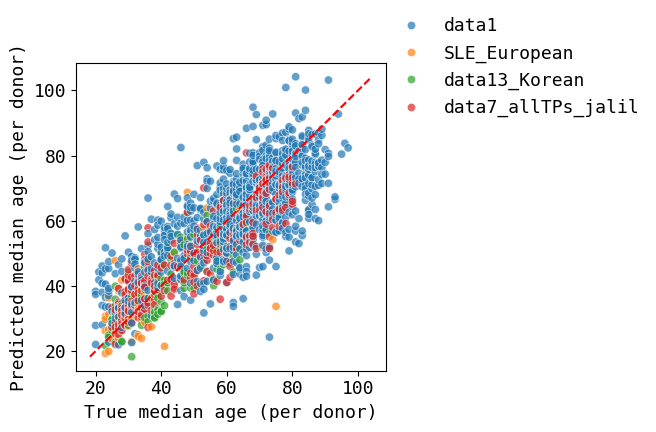

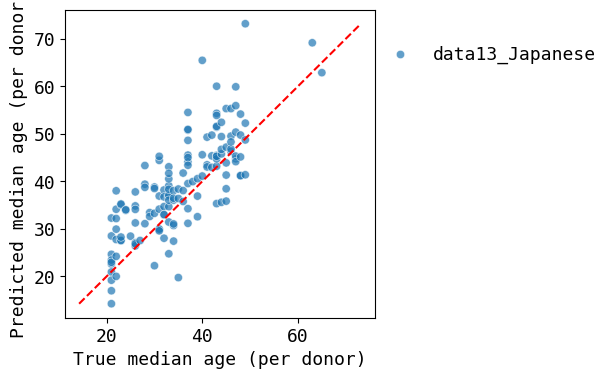

In [10]:
for cell_type in ['CD8T']:
    adata_train_bulk_t = adata_train_bulk[adata_train_bulk.obs['cell_type'] == cell_type].copy()
    adata_test_bulk_t = adata_test_bulk[adata_test_bulk.obs['cell_type'] == cell_type].copy()
    obj = age_predictor()
    obj.train_cv(adata_train_bulk_t)
    obj.train(adata_train_bulk_t)
    obj.predict(adata_test_bulk_t)

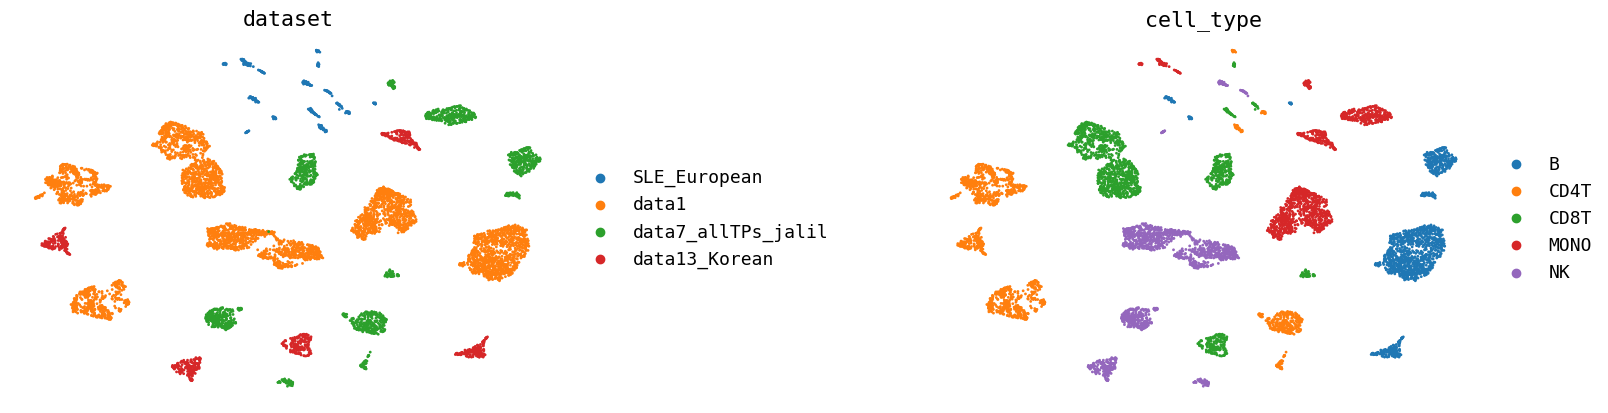

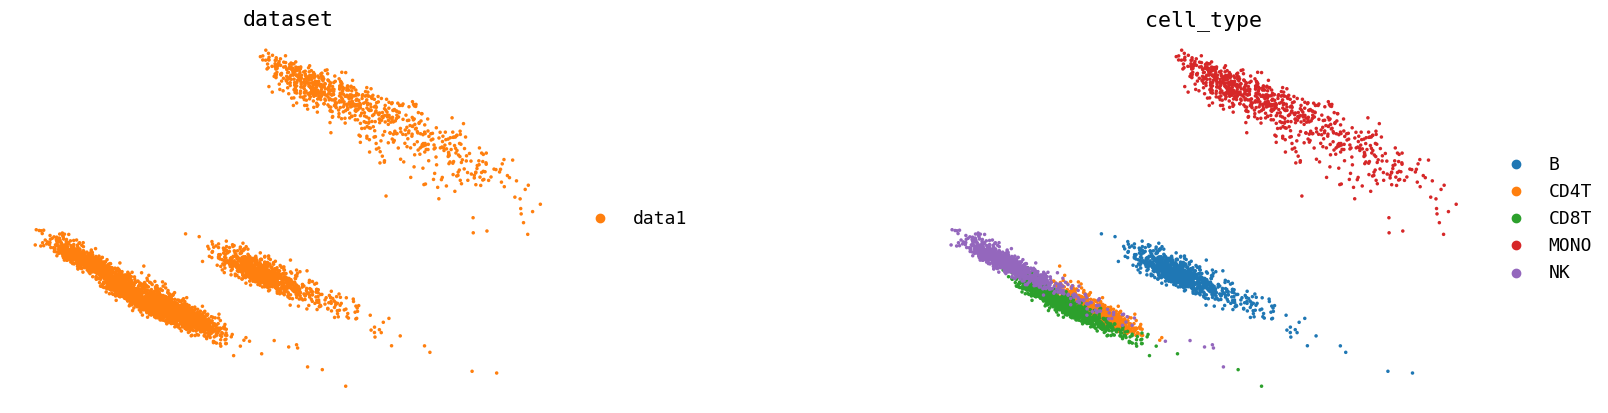

In [17]:
# - original data embedding
if True:
    adata_raw = adata_train.copy()
    if data_type=='sc':
        sc.pp.normalize_total(adata_raw)
        sc.pp.log1p(adata_raw)
    # sc.pp.highly_variable_genes(adata_raw, n_top_genes=2000, subset=True)
    sc.pp.pca(adata_raw)
    wrapper_umap(adata_raw)

    sc.pl.pca(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

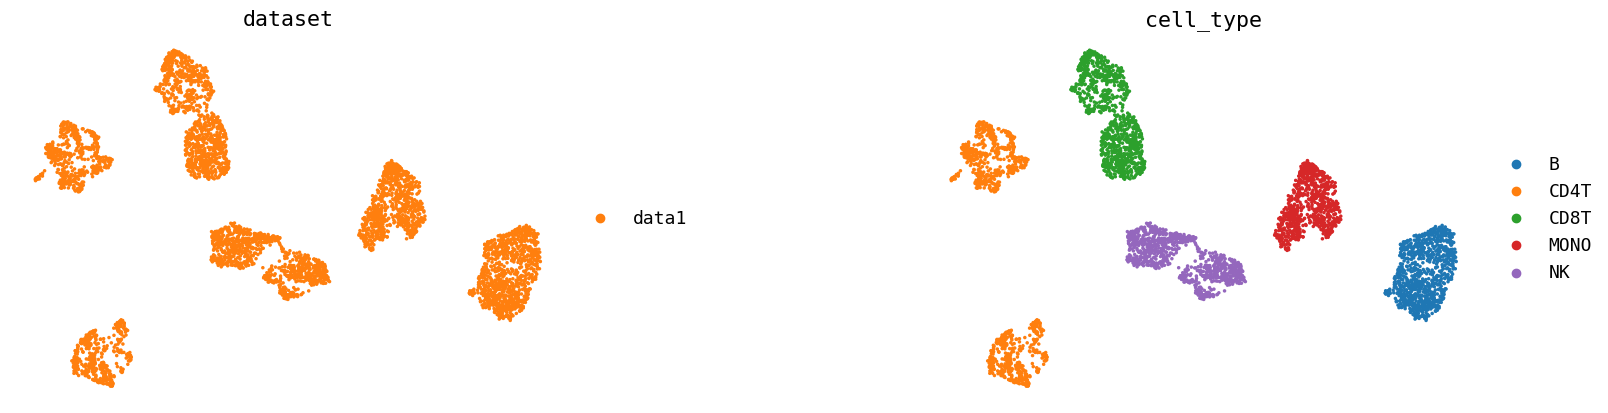

In [ ]:
sc.pl.umap(adata_raw[adata_raw.obs['dataset'] == 'data1'],
            color=['dataset', 'cell_type'],
            frameon=False,
            wspace=0.5)

In [19]:
aaa

NameError: name 'aaa' is not defined

# Train

In [34]:
import seaborn as sns
from typing import Optional
import pandas as pd
import numpy as np
from scipy import sparse
from anndata import AnnData
import scanpy as sc
import torch
torch.set_float32_matmul_precision('medium')
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import cpa
from hiara.src.clock.NN.helper import  get_params, data_type, cell_type_train, save_path_train, save_path_test, batch_key
from hiara.src.clock.helper import format_data
from hiara.src.config import aging_clock_train_datasets as train_datasets

model_params, trainer_params = get_params(data_type)

print("Training mode activated.")
assert len(train_datasets)>0, "Training mode requires at least one training dataset."
print('Loading training data ... ')
adata = format_data(train_datasets, cell_type_train, data_type, only_ctr=True, only_targets=False)

Training mode activated.
Loading training data ... 
Using layer X_norm
Datasets in merged adata: ['data1' 'data7_allTPs_jalil' 'SLE_European' 'data13_Korean'
 'data13_Japanese' 'data12' 'op' 'CXCL9']
Conditions in merged adata: ['normal' 'Dimethyl Sulfoxide' '24 h RPMI']
Cell types in merged adata: ['B', 'CD4T', 'CD8T', 'MONO', 'NK']
Categories (5, object): ['B', 'CD4T', 'CD8T', 'MONO', 'NK']


In [51]:
cpa.CPA.wrapper_setup_data(adata, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train)
model = cpa.CPA(adata=adata,
                include_age_head=True,
                **model_params,
            )
model.train(max_epochs=200,
    use_gpu=True,
    batch_size=128 if data_type == 'sc' else 32,
    plan_kwargs=trainer_params,
    early_stopping_patience=5,
    check_val_every_n_epoch=20,
    save_path=save_path_train,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 2/2: 100%|██████████| 2/2 [00:24<00:00, 12.14s/it, v_num=1, recon=3.62e+3, adv_loss=3, age_loss=nan, acc_dataset=0.553, acc_cell_type=0.255] 

`Trainer.fit` stopped: `max_epochs=2` reached.


Epoch 2/2: 100%|██████████| 2/2 [00:24<00:00, 12.15s/it, v_num=1, recon=3.62e+3, adv_loss=3, age_loss=nan, acc_dataset=0.553, acc_cell_type=0.255]


In [4]:
!bash ../scripts/run_train_nn.sh

Running training ...
[rank: 0] Global seed set to 0
Traceback (most recent call last):
  File "/home/jnourisa/projs/ongoing/hiara/src/clock/NN/script_train.py", line 14, in <module>
    from hiara.src.clock.NN.helper import  format_data, train_datasets, test_datasets, get_params, data_type, cell_type_train, save_path_train, save_path_test, batch_key
ImportError: cannot import name 'format_data' from 'hiara.src.clock.NN.helper' (/home/jnourisa/projs/ongoing/hiara/src/clock/NN/helper.py)


# Evaluate on train data

-TODO: 1. train with the original version. 2. reduce the epock, 3. make it 'nb'. 4. train with larger datasets 

/vol/projects/jnourisa//output//NN/bulk_train


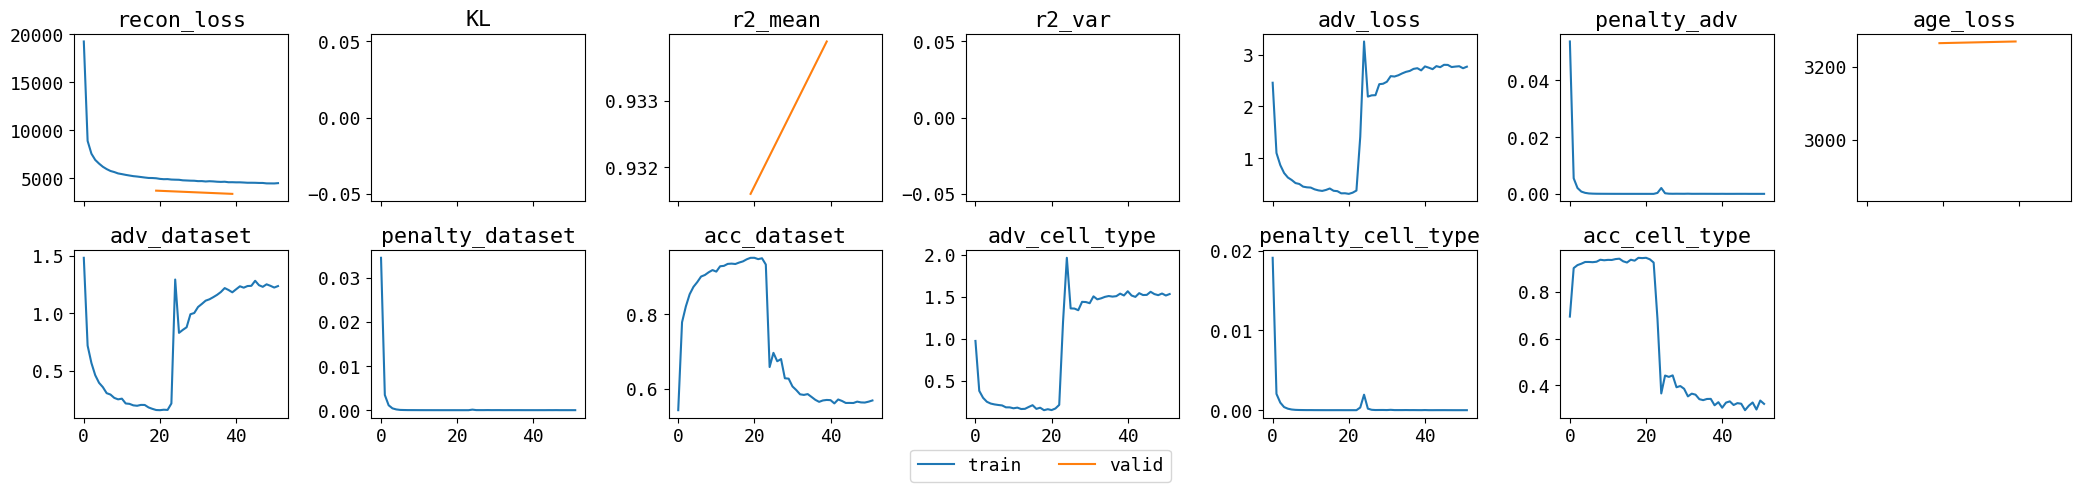

In [36]:
import cpa
# from hiara.src.config import save_dir
# save_path_train=f'{save_dir}/NN/try1' # trained with cleaned cpa, zinb, ['SLE_European', 'data12', 'data13_Korean']
print(save_path_train)
# model = cpa.CPA.load(dir_path=save_path_train)
plot_history(model)

In [37]:
adata = model.adata
cpa.CPA.wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)
latent_dict = model.get_latent_representation(adata=adata)

Setting up data without cell type filtering.
registred datasets:  ['CXCL9' 'SLE_European' 'data1' 'data7_allTPs_jalil' 'data12'
 'data13_Japanese' 'data13_Korean' 'op']


100%|██████████| 270/270 [00:02<00:00, 133.64it/s]


Epoch 95/200:  47%|████▋     | 94/200 [1:32:25<1:44:13, 59.00s/it, v_num=1, recon=3.31e+3, adv_loss=1.23, age_loss=146, acc_dataset=0.564, val_recon=3.02e+3, val_r2_mean=0.931, val_KL=nan]


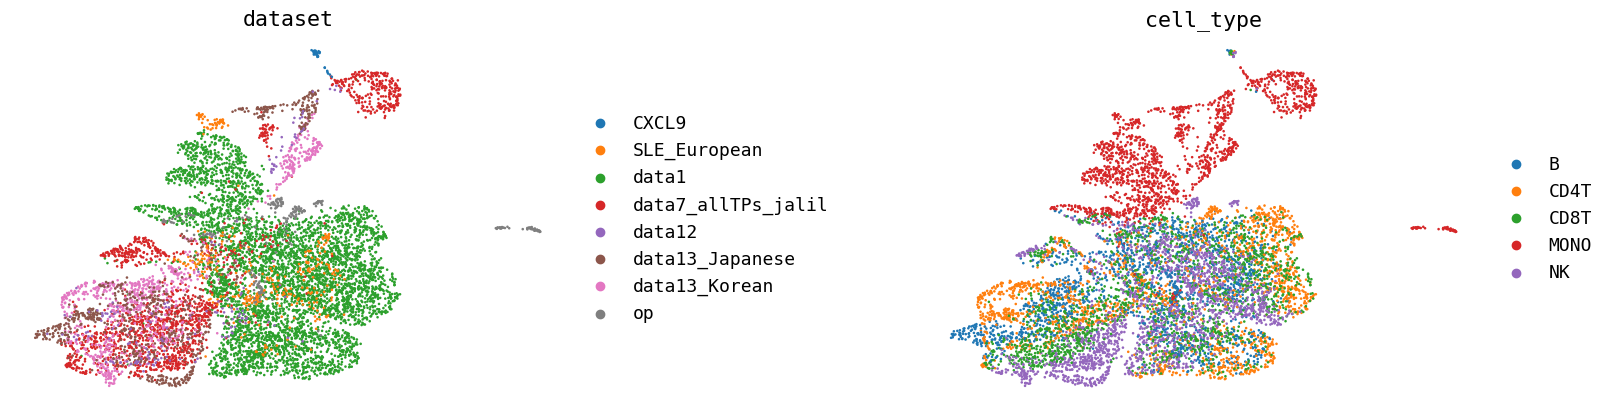

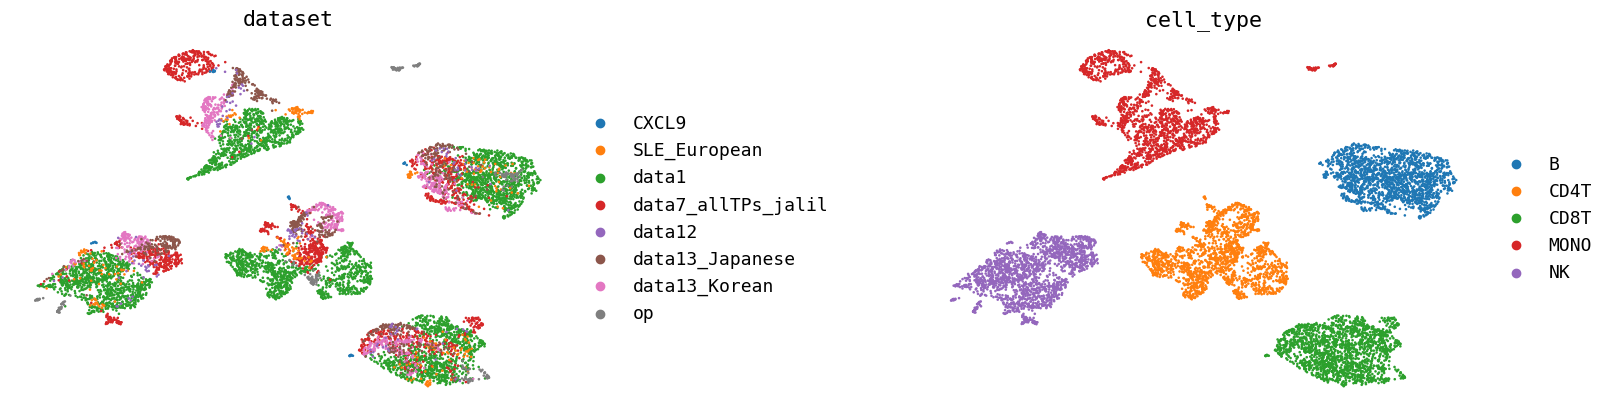

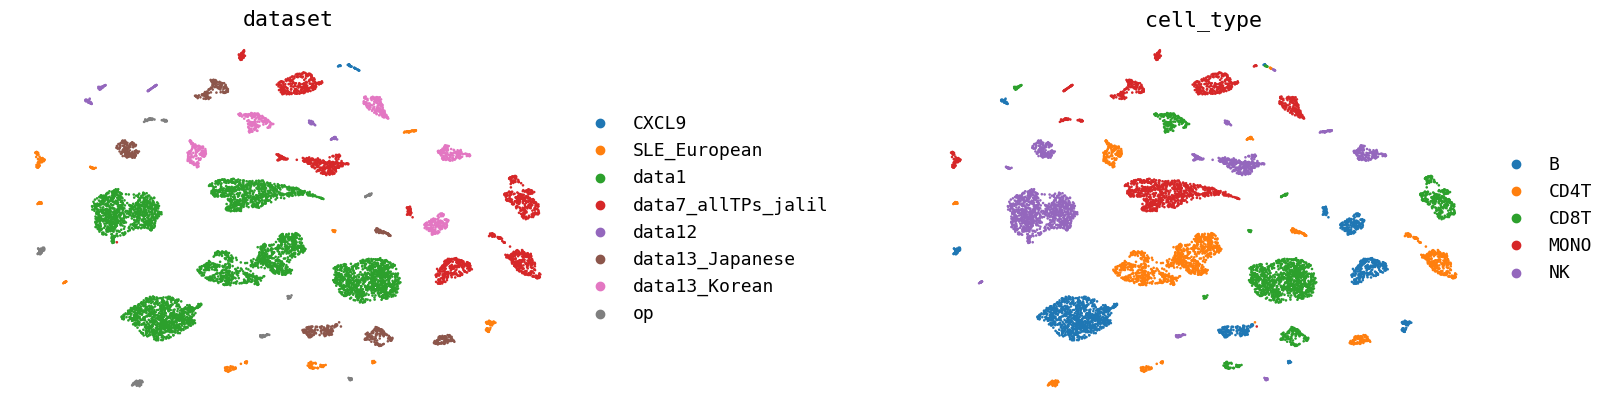

In [38]:
if True:
    wrapper_umap(latent_dict['latent_basal'])
    wrapper_umap(latent_dict['latent_corrected'])
    wrapper_umap(latent_dict['latent_after'])

In [48]:
cpa.CPA.wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)
model.predict_age(adata)

Setting up data without cell type filtering.
registred datasets:  ['CXCL9' 'SLE_European' 'data1' 'data12' 'data13_Japanese' 'data13_Korean'
 'data7_allTPs_jalil' 'op']


100%|██████████| 92/92 [00:02<00:00, 45.12it/s]


Spearman correlation (per donor): 0.70, R² (per donor): 0.46


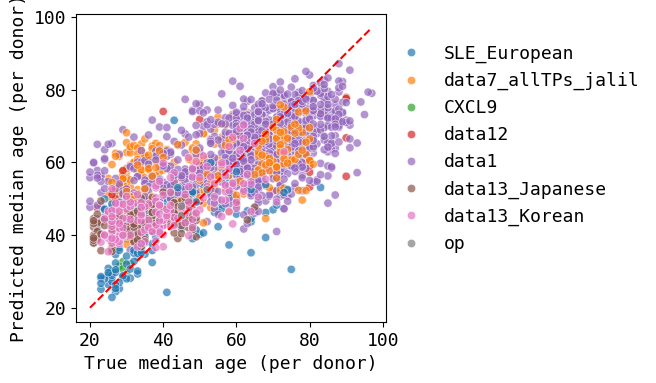

In [50]:
# adata.obs['age_predicted']
cell_type = 'CD4T'
adata_t = adata[adata.obs['cell_type'] == cell_type].copy()
age_predictor.evaluate(
    y_pred=adata_t.obs['age_predicted'], y_test=adata_t.obs['age'], 
    group_all=adata_t.obs['donor_age'], batch_all=adata_t.obs['dataset'])

Spearman correlation (per donor): -0.13, R² (per donor): -1.39


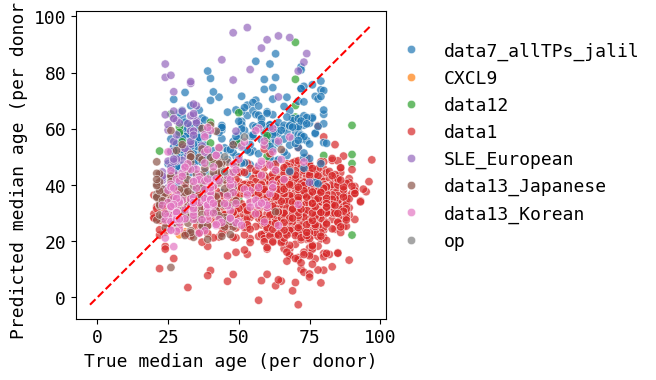

In [41]:
adata_corrected = latent_dict['latent_basal'].copy()
adata_corrected_t = adata_corrected[adata_corrected.obs['cell_type'] == cell_type].copy()
obj = age_predictor()
obj.train_cv(adata_corrected_t)
# obj.predict(adata_test_bulk_t)

Using layer X_norm
Datasets in merged adata: ['data1' 'data7_allTPs_jalil' 'SLE_European' 'data13_Korean'
 'data13_Japanese' 'data12' 'op' 'CXCL9']
Conditions in merged adata: ['normal' 'systemic lupus erythematosus' 'TIE2 Kinase Inhibitor' 'MK-5108'
 'Lapatinib' 'Belinostat' 'Dabrafenib' 'Dimethyl Sulfoxide' 'Atorvastatin'
 'Ganetespib (STA-9090)' 'Clomipramine' 'Sunitinib' 'Tivozanib'
 'Tamatinib' 'Ixabepilone' 'Linagliptin'
 '5-(9-Isopropyl-8-methyl-2-morpholino-9H-purin-6-yl)pyrimidin-2-amine'
 'O-Demethylated Adapalene' 'Protriptyline' 'I-BET151' 'Foretinib'
 'GW843682X' 'Raloxifene' 'Topotecan' 'BAY 87-2243' 'Phenylbutazone'
 'K-02288' 'BMS-777607' 'Porcn Inhibitor III' 'TL_HRAS26' 'Vorinostat'
 'BMS-265246' 'Ruxolitinib' 'Pomalidomide' 'Dovitinib' 'AVL-292'
 'Navitoclax' 'Methotrexate' 'Palbociclib' 'Trametinib'
 'AMD-070 (hydrochloride)' 'Sgc-cbp30' 'FK 866' 'Chlorpheniramine'
 'Scriptaid' 'BAY 61-3606' 'LY2090314' 'Vardenafil' 'Dasatinib' 'AT13387'
 'PF-04691502' 'Perhexiline'

100%|██████████| 92/92 [00:02<00:00, 41.22it/s]


Spearman correlation (per donor): 0.51, R² (per donor): -1.72


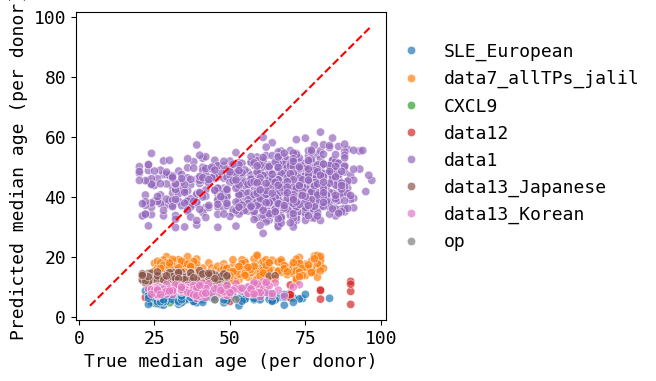

In [42]:
adata = format_data(train_datasets, cell_type_train, data_type, only_ctr=False)
cpa.CPA.wrapper_setup_data(adata, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)

model.predict_age(adata)
adata_t = adata[adata.obs['cell_type'] == cell_type].copy()
age_predictor.evaluate(
    y_pred=adata_t.obs['age_predicted'], y_test=adata_t.obs['age'], 
    group_all=adata_t.obs['donor_age'], batch_all=adata_t.obs['dataset'])


In [43]:
print(adata[(adata.obs['cell_type']=='CD4T') & (adata.obs['dataset']=='parsebioscience') & (adata.obs['condition'].isin(['PBS', 'IL-10']))].obs.groupby(['condition'])['age_predicted'].mean())
print(adata[(adata.obs['cell_type']=='CD8T') & (adata.obs['dataset']=='parsebioscience') & (adata.obs['condition'].isin(['PBS', 'IL-10']))].obs.groupby(['condition'])['age_predicted'].mean())

print(adata[(adata.obs['cell_type']=='CD8T') & (adata.obs['dataset']=='op') & (adata.obs['condition'].isin(['Dimethyl Sulfoxide', 'Ruxolitinib']))].obs.groupby(['condition'])['age_predicted'].mean())
print(adata[(adata.obs['cell_type']=='CD4T') & (adata.obs['dataset']=='op') & (adata.obs['condition'].isin(['Dimethyl Sulfoxide', 'Ruxolitinib']))].obs.groupby(['condition'])['age_predicted'].mean())

print(adata[(adata.obs['cell_type']=='CD4T') & (adata.obs['dataset']=='CXCL9') & (adata.obs['condition'].isin(['24 h RPMI', '24 h RPMI + ruxolitinib']))].obs.groupby(['condition'])['age_predicted'].mean())
print(adata[(adata.obs['cell_type']=='CD8T') & (adata.obs['dataset']=='CXCL9') & (adata.obs['condition'].isin(['24 h LPS', '24 h LPS + ruxolitinib']))].obs.groupby(['condition'])['age_predicted'].mean())


Series([], Name: age_predicted, dtype: float32)
Series([], Name: age_predicted, dtype: float32)
condition
Dimethyl Sulfoxide    2.832557
Ruxolitinib           1.902589
Name: age_predicted, dtype: float32
condition
Dimethyl Sulfoxide    6.090408
Ruxolitinib           5.306414
Name: age_predicted, dtype: float32
condition
24 h RPMI                  5.274765
24 h RPMI + ruxolitinib    5.122170
Name: age_predicted, dtype: float32
condition
24 h LPS                  3.156550
24 h LPS + ruxolitinib    3.054225
Name: age_predicted, dtype: float32


In [44]:
# adata.write(f'{save_dir}/gene_expression_smoothed/adata_latent_corrected.h5ad')

In [45]:
aaa

NameError: name 'aaa' is not defined

# Train on test data

## Zero shot

In [58]:
print('Loading test data ... ')
adata_test = format_data(test_datasets, cell_type_train, data_type)

Loading test data ... 


In [59]:
def integrate_test_data(model, adata_test, batch_key):
    new_batches = adata_test.obs[batch_key].unique()
    if batch_key not in model.covars_encoder:
        raise ValueError(f"Batch key '{batch_key}' not found in covariates encoder. Please ensure the batch key is correctly set.")
    existing_batches = set(model.covars_encoder[batch_key])

    # if set(new_batches).issubset(existing_batches):
    #     print(f"Batch '{new_batches}' already exists in the model. No need to extend embedding.")
    #     return

    from hiara.src.clock.helper import align_feature_space
    gene_names = model.adata.var_names
    adata_test = align_feature_space(adata_test, gene_names)
    print('Extending embedding for test dataset ... ')
    model.module.extend_embedding(covariate=batch_key, new_keys=new_batches)

    model.wrapper_setup_data(adata=adata_test, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train, initial_setup=False)
    # Freeze all other self.module parameters
    for name, param in model.module.named_parameters():
        if f'covars_embeddings.{batch_key}.weight' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    # - check trainable params
    for name, param in model.module.named_parameters():
        if param.requires_grad:
            print(f"{name}: trainable")
        else:
            # print(f"{name}: frozen (requires_grad=False)")
            pass
    return model, adata_test
import copy
print('Loading model ... ')
model = cpa.CPA.load(dir_path=save_path_train)
model, adata_test = integrate_test_data(model, adata_test, batch_key=batch_key)

Loading model ... 
INFO     File /home/jnourisa/projs/ongoing/hiara//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']
Extending embedding for test dataset ... 
Setting up data without cell type filtering.
Loading settings from registry. Given batch key and covariates will be ignored.
registred datasets:  ['data12' 'data13_Japanese']
covars_embeddings.dataset.weight: trainable


In [60]:
adata_train = format_data(train_datasets, cell_type_train, data_type)

In [61]:
adata_all = ad.concat([adata_train, adata_test])
model.wrapper_setup_data(adata=adata_all, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train, initial_setup=False)
latent_dict = model.get_latent_representation(adata=adata_all)


Setting up data without cell type filtering.
Loading settings from registry. Given batch key and covariates will be ignored.
registred datasets:  ['SLE_European' 'data1' 'data12' 'data13_Japanese' 'data13_Korean'
 'data7_allTPs_jalil']


100%|██████████| 262/262 [00:00<00:00, 335.93it/s]


Epoch 1/200:   0%|          | 0/200 [1:27:21<?, ?it/s]


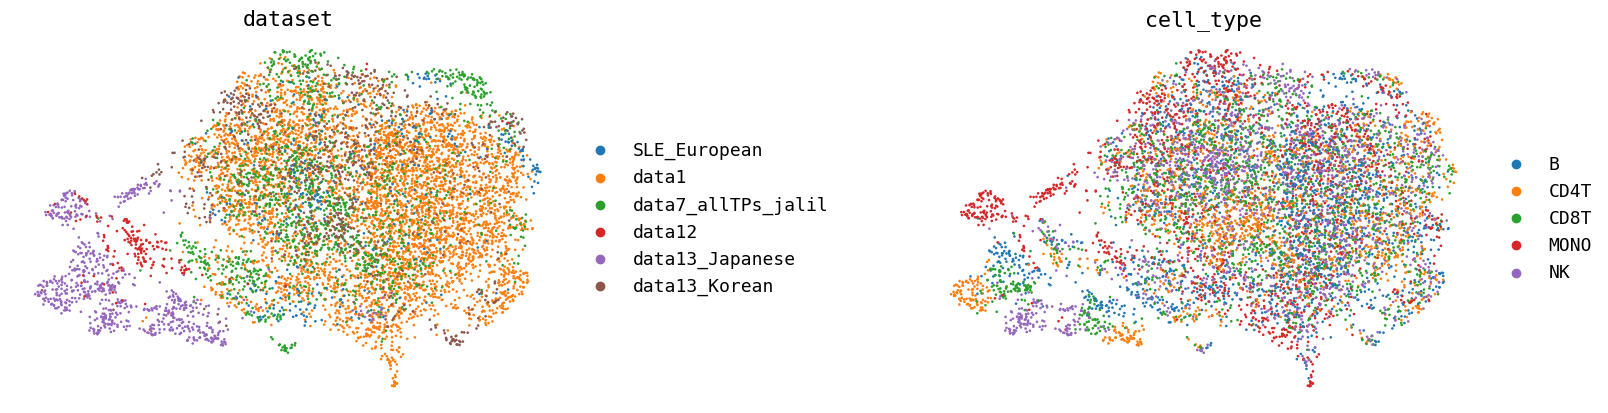

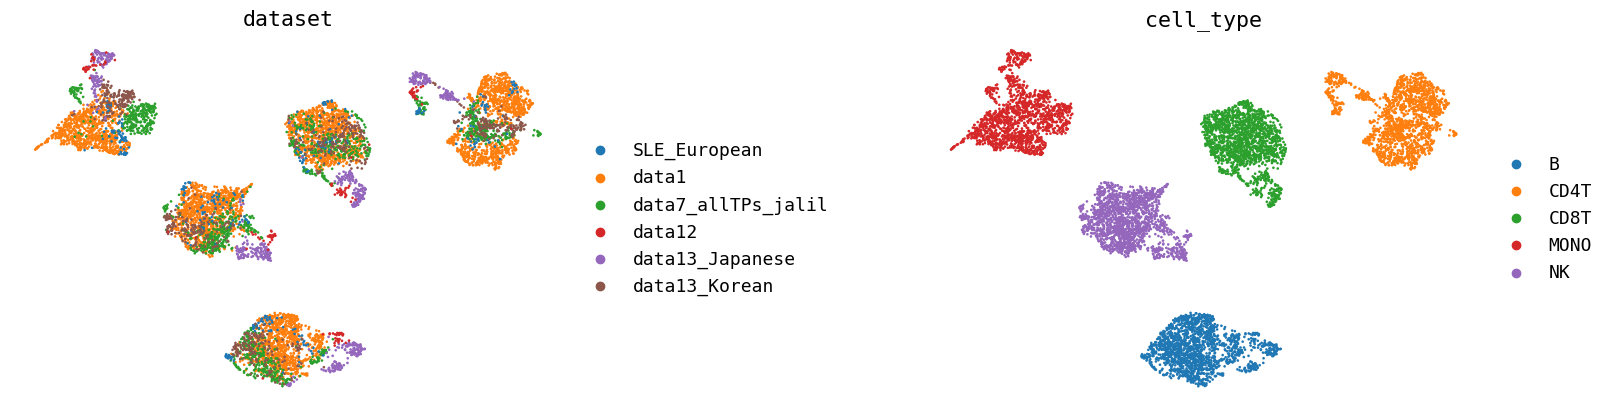

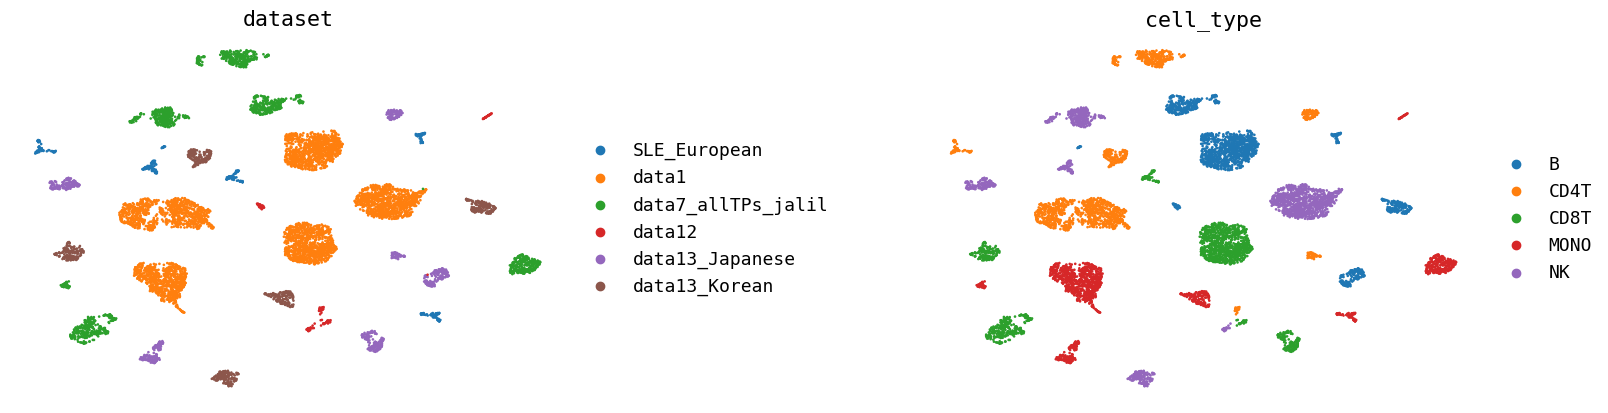

In [62]:
if True:
    wrapper_umap(latent_dict['latent_basal'])
    wrapper_umap(latent_dict['latent_corrected'])
    wrapper_umap(latent_dict['latent_after'])

100%|██████████| 8/8 [00:00<00:00, 129.91it/s]

Spearman correlation (per donor): 0.27, R² (per donor): -0.58


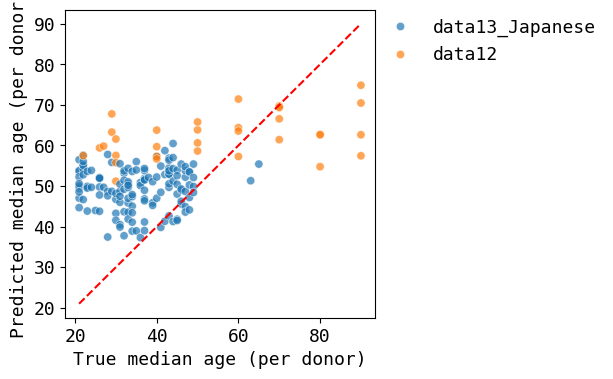

In [63]:
model.predict_age(adata_test, extend_categories=True)
age_predictor.evaluate(
    y_pred=adata_test.obs['age_predicted'], y_test=adata_test.obs['age'], 
    group_all=adata_test.obs['donor_age'], batch_all=adata_test.obs['dataset'])

Spearman correlation (per donor): 0.75, R² (per donor): 0.57


Spearman correlation (per donor): 0.38, R² (per donor): -1.73


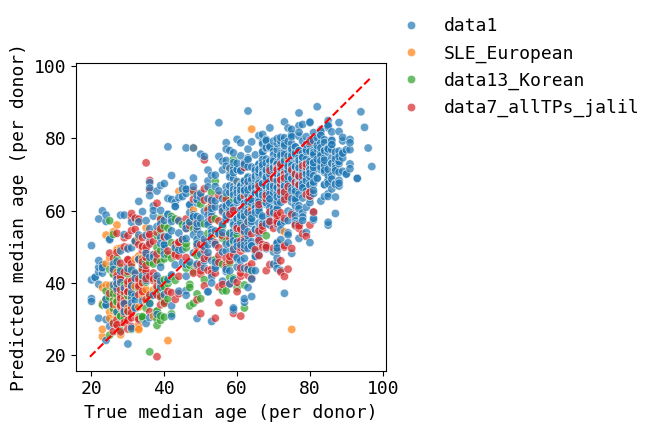

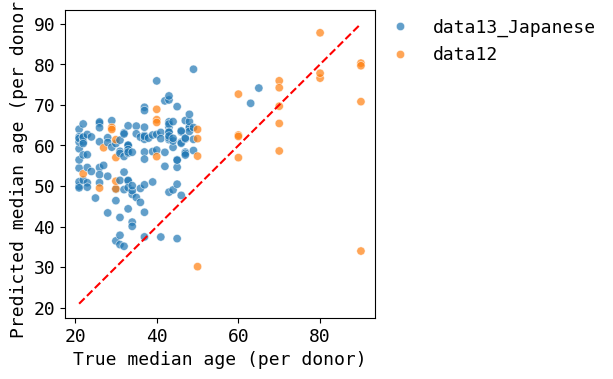

In [64]:
adata_corrected = latent_dict['latent_corrected']

if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train_cv(adata_corrected_train)
obj = age_predictor()
obj.train(adata_corrected_train)
adata_corrected_test = obj.predict(adata_corrected_test)

## Fine tunning

In [65]:
def integrate_test_data(model, adata_test, batch_key):
    new_batches = adata_test.obs[batch_key].unique()
    if batch_key not in model.covars_encoder:
        raise ValueError(f"Batch key '{batch_key}' not found in covariates encoder. Please ensure the batch key is correctly set.")
    existing_batches = set(model.covars_encoder[batch_key])

    # if set(new_batches).issubset(existing_batches):
    #     print(f"Batch '{new_batches}' already exists in the model. No need to extend embedding.")
    #     return

    from hiara.src.clock.helper import align_feature_space
    gene_names = model.adata.var_names
    adata_test = align_feature_space(adata_test, gene_names)
    print('Extending embedding for test dataset ... ')
    model.module.extend_embedding(covariate=batch_key, new_keys=new_batches)

    model.wrapper_setup_data(adata=adata_test, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train, initial_setup=False)
    # Freeze all other self.module parameters
    for name, param in model.module.named_parameters():
        if f'covars_embeddings.{batch_key}.weight' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False
    # - check trainable params
    for name, param in model.module.named_parameters():
        if param.requires_grad:
            print(f"{name}: trainable")
        else:
            # print(f"{name}: frozen (requires_grad=False)")
            pass
    return model, adata_test
import copy
print('Loading model ... ')
model = cpa.CPA.load(dir_path=save_path_train)
model, adata_test = integrate_test_data(model, adata_test, batch_key=batch_key)

model._register_manager_for_instance(
                        model.adata_manager.transfer_fields(adata_test, extend_categories=True)
                )
model.adata = adata_test

Loading model ... 
INFO     File /home/jnourisa/projs/ongoing/hiara//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']
Extending embedding for test dataset ... 
Setting up data without cell type filtering.
Loading settings from registry. Given batch key and covariates will be ignored.
registred datasets:  ['data12' 'data13_Japanese']
covars_embeddings.dataset.weight: trainable


In [66]:
trainer_params = {
        "n_epochs_kl_warmup": None,
        "n_epochs_pretrain_ae": 1,
        "n_epochs_adv_warmup": 1,
        "n_epochs_mixup_warmup": 0,
        "mixup_alpha": 0.0,
        "use_batch_norm_adv": True,
        "use_layer_norm_adv": False,
        "dropout_rate_adv": 0.3,
        "reg_adv": 20,
        "pen_adv": 5,
        "lr": 0.0003,
        "wd": 0,
        "adv_lr": 0.0003,
        "adv_wd": 0,
        "adv_loss": "cce",
        "do_clip_grad": True,
        "gradient_clip_value": 1.0,
        "step_size_lr": 10,
    }
model.train(max_epochs=200,
        initial_training = False,
        use_gpu=True,
        batch_size=10,
        plan_kwargs=trainer_params,
        early_stopping_patience=5,
        check_val_every_n_epoch=20,
        save_path=save_path_test,
    )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 20/200:  10%|▉         | 19/200 [00:16<02:32,  1.18it/s, v_num=1, recon=1.55e+4, adv_loss=nan, age_loss=nan, acc_dataset=nan, acc_cell_type=nan]


Epoch 00019: cpa_metric reached. Module best state updated.


Epoch 120/200:  60%|██████    | 120/200 [01:42<01:08,  1.17it/s, v_num=1, recon=9.6e+3, adv_loss=nan, age_loss=nan, acc_dataset=nan, acc_cell_type=nan, val_recon=8.4e+3, val_r2_mean=0.882, val_KL=nan]  


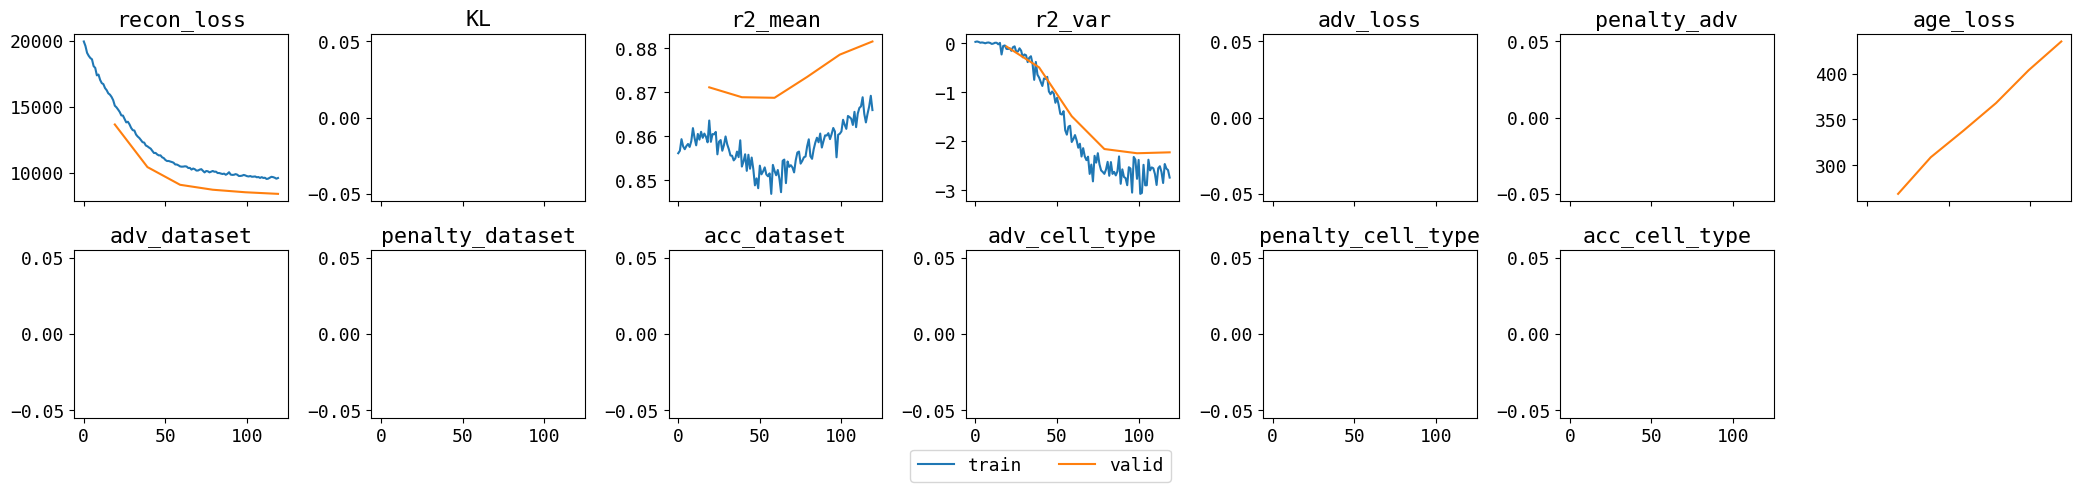

In [67]:
plot_history(model)

# Evaluate on test data

In [68]:
adata_train = format_data(train_datasets, cell_type_train, data_type)
adata_test = format_data(test_datasets, cell_type_train, data_type)
adata_test = align_feature_space(adata_test, adata_train.var_names)

In [69]:
model_test = cpa.CPA.load(dir_path=save_path_test)
model_train = cpa.CPA.load(dir_path=save_path_train)
model_test.module.encoder.load_state_dict(model_train.module.encoder.state_dict())

INFO     File /home/jnourisa/projs/ongoing/hiara//output//NN/bulk_test/model.pt already downloaded                  


[rank: 0] Global seed set to 6977


registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil' 'data12'
 'data13_Japanese']
INFO     File /home/jnourisa/projs/ongoing/hiara//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


registred datasets:  ['SLE_European' 'data1' 'data13_Korean' 'data7_allTPs_jalil']


<All keys matched successfully>

In [70]:
import anndata as ad
adata_all = ad.concat([adata_train, adata_test], axis=0)
model.wrapper_setup_data(adata=adata_all, batch_key=batch_key, data_type=data_type, cell_type=cell_type_train, initial_setup=False)
latent_dict = model_test.get_latent_representation(adata=adata_all, extend_categories=True)

Setting up data without cell type filtering.
Loading settings from registry. Given batch key and covariates will be ignored.
registred datasets:  ['SLE_European' 'data1' 'data12' 'data13_Japanese' 'data13_Korean'
 'data7_allTPs_jalil']


100%|██████████| 262/262 [00:00<00:00, 296.61it/s]


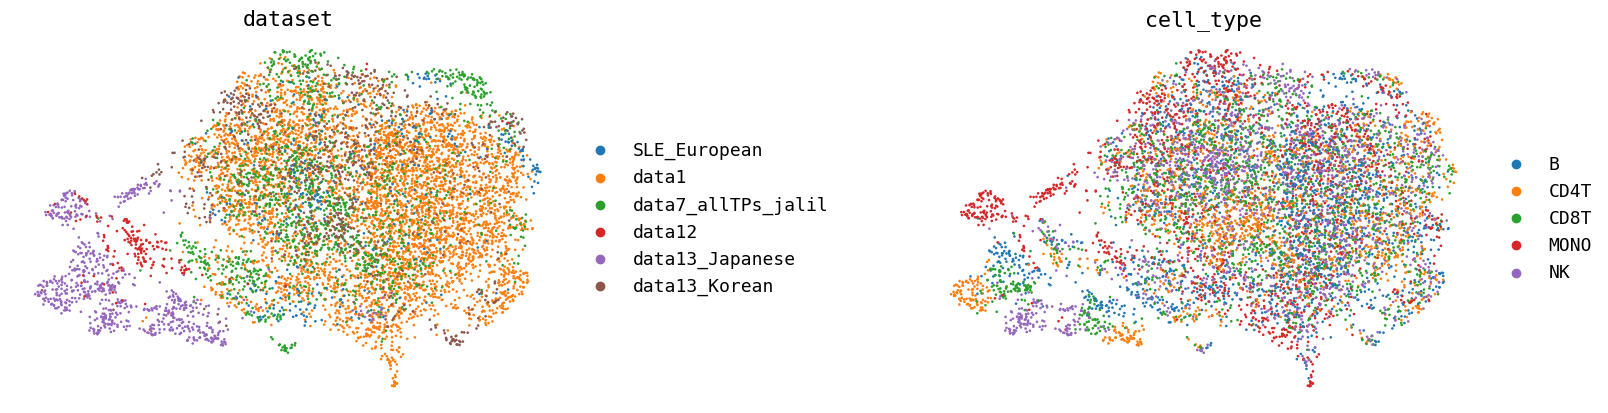

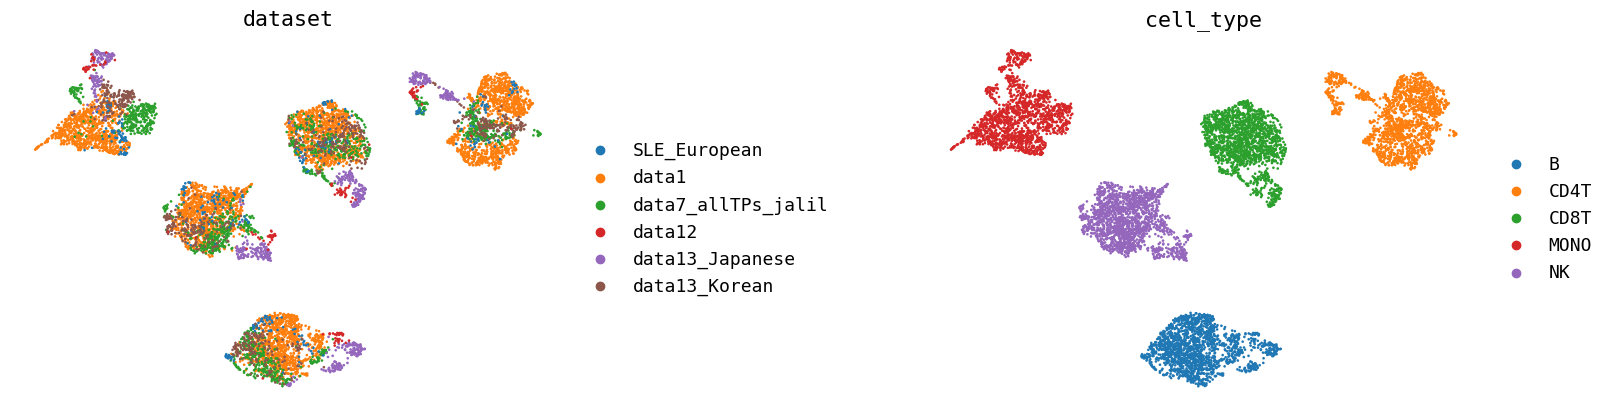

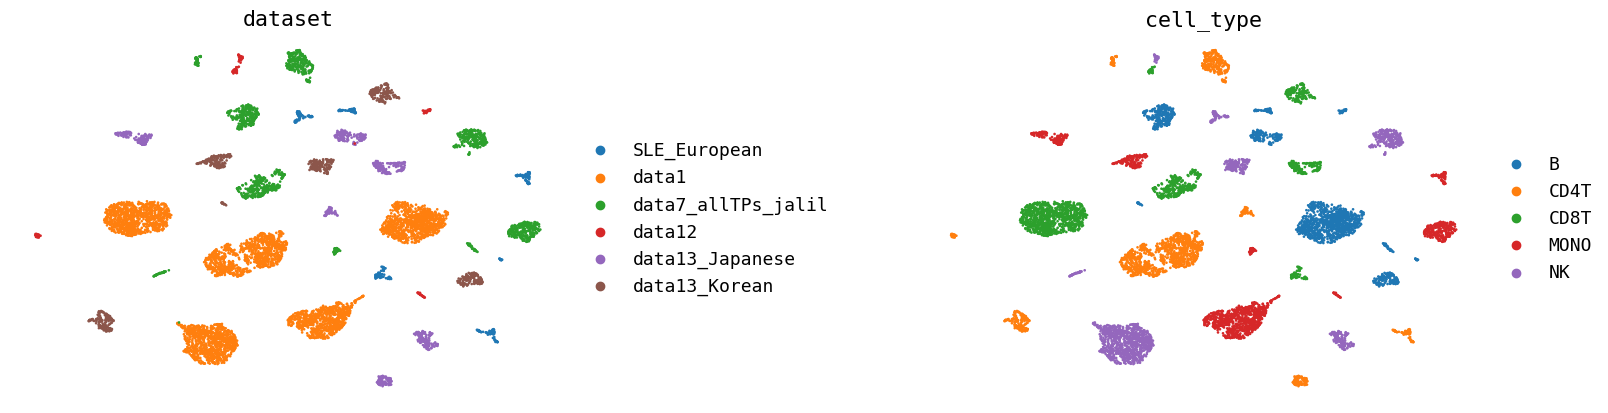

In [71]:
wrapper_umap(latent_dict['latent_basal'])
wrapper_umap(latent_dict['latent_corrected'])
wrapper_umap(latent_dict['latent_after'])

Spearman correlation (per donor): 0.38, R² (per donor): -1.73


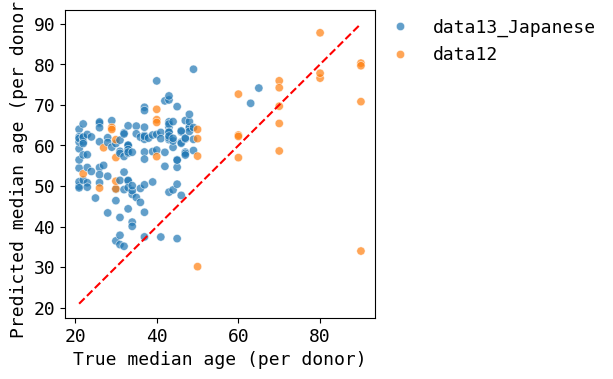

In [74]:
adata_corrected = latent_dict['latent_corrected']

if data_type == 'sc':
    adata_corrected_bulk = bulkify_func(adata_corrected, covariates=['cell_type', 'donor_id', 'age'])
else:
    adata_corrected_bulk = adata_corrected

adata_corrected_bulk = adata_corrected_bulk[adata_corrected_bulk.obs['cell_type'] == 'CD8T'].copy()

adata_corrected_train = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(train_datasets)].copy()
adata_corrected_test = adata_corrected_bulk[adata_corrected_bulk.obs['dataset'].isin(test_datasets)].copy()

obj = age_predictor()
obj.train(adata_corrected_train)
adata_corrected_test = obj.predict(adata_corrected_test)

In [73]:
aaa

NameError: name 'aaa' is not defined

# Sanity check

In [ ]:
model_test = cpa.CPA.load(dir_path=save_path_test)
model_train = cpa.CPA.load(dir_path=save_path_train)

INFO     File /home/jnourisa/projs/ongoing/hiara//output//NN/bulk_test/model.pt already downloaded                  


[rank: 0] Global seed set to 6977


INFO     File /home/jnourisa/projs/ongoing/hiara//output//NN/bulk_train/model.pt already downloaded                 


[rank: 0] Global seed set to 6977


In [ ]:
torch.equal(
    model_train.module.covars_embeddings['dataset'].weight[:4],
    model_test.module.covars_embeddings['dataset'].weight[:4]
)

True

In [124]:
for (name1, p1), (name2, p2) in zip(
    model_train.module.encoder.named_parameters(),
    model_test.module.encoder.named_parameters()
):
    assert name1 == name2, f"Parameter name mismatch: {name1} vs {name2}"

    if torch.equal(p1, p2):
        print(f"{name1}: ✅ equal")
    else:
        diff = (p1 - p2).abs().max().item()
        print(f"{name1}: ❌ not equal (max abs diff = {diff:.6g})")

network.fc_layers.Layer 0.0.weight: ✅ equal
network.fc_layers.Layer 0.0.bias: ✅ equal
network.fc_layers.Layer 0.1.weight: ✅ equal
network.fc_layers.Layer 0.1.bias: ✅ equal
network.fc_layers.Layer 1.0.weight: ✅ equal
network.fc_layers.Layer 1.0.bias: ✅ equal
network.fc_layers.Layer 1.1.weight: ✅ equal
network.fc_layers.Layer 1.1.bias: ✅ equal
z.weight: ✅ equal
z.bias: ✅ equal


In [ ]:
for (name1, b1), (name2, b2) in zip(
    model_train.module.encoder.named_buffers(),
    model_test.module.encoder.named_buffers()
):
    assert name1 == name2, f"Buffer name mismatch: {name1} vs {name2}"
    if torch.equal(b1, b2):
        print(f"{name1}: ✅ equal")
    else:
        diff = (b1 - b2).abs().max().item()
        print(f"{name1}: ❌ not equal (max abs diff = {diff:.6g})")

network.fc_layers.Layer 0.1.running_mean: ✅ equal
network.fc_layers.Layer 0.1.running_var: ✅ equal
network.fc_layers.Layer 0.1.num_batches_tracked: ✅ equal
network.fc_layers.Layer 1.1.running_mean: ✅ equal
network.fc_layers.Layer 1.1.running_var: ✅ equal
network.fc_layers.Layer 1.1.num_batches_tracked: ✅ equal


In [95]:
skip_params = {
    "covars_embeddings.dataset.weight",  # full name for consistency
}

for (name1, p1), (name2, p2) in zip(
    model_train.module.named_parameters(),
    model_test.module.named_parameters()
):
    assert name1 == name2, f"Parameter order mismatch: {name1} vs {name2}"
    if name1 in skip_params:
        continue  # skip this one, you'll check manually later
    if not torch.equal(p1, p2):
        print(f"Mismatch found in {name1}")

In [9]:
wrapper_setup_data(adata_train, data_type=data_type, batch_key=batch_key, cell_type=cell_type_train)


Setting up data without cell type filtering.


In [ ]:
model_train.get_latent_representation(adata=adata_train, extend_categories=False)

  0%|          | 0/234 [00:00<?, ?it/s]

tensor([[ 0.3668,  0.5763, -0.3707,  ..., -1.0492,  0.3145,  0.6911],
        [ 0.9585, -0.2704, -1.4242,  ..., -1.2661, -0.9068,  0.9495],
        [ 0.4969,  0.6925, -0.3955,  ..., -1.2393, -0.1686,  0.9456],
        ...,
        [ 1.2864, -0.9844, -0.8084,  ..., -2.5286, -0.5195,  2.4228],
        [ 2.5081, -1.7721, -1.6863,  ..., -0.4522, -3.0076,  0.2014],
        [ 3.4733, -1.5788, -2.0648,  ..., -1.6358, -3.6092,  1.7245]],
       device='cuda:0')


SystemExit: 1

In [42]:
model_test.get_latent_representation(adata=adata_train, extend_categories=False)

  0%|          | 0/234 [00:00<?, ?it/s]

tensor([[ 0.3668,  0.5763, -0.3707,  ..., -1.0492,  0.3145,  0.6911],
        [ 0.9585, -0.2704, -1.4242,  ..., -1.2661, -0.9068,  0.9495],
        [ 0.4969,  0.6925, -0.3955,  ..., -1.2393, -0.1686,  0.9456],
        ...,
        [ 1.2864, -0.9844, -0.8084,  ..., -2.5286, -0.5195,  2.4228],
        [ 2.5081, -1.7721, -1.6863,  ..., -0.4522, -3.0076,  0.2014],
        [ 3.4733, -1.5788, -2.0648,  ..., -1.6358, -3.6092,  1.7245]],
       device='cuda:0')


SystemExit: 1